# NY Case Dataset — Summary Statistics

Two different populations, kept clearly separate:

1. **Full case population** — every case metadata JSON already exported to
   `data/cases/ny_after_search` (~29,728 cases, all of
   `courts_final.ny_cases_after_search`). No PDFs/text here, just docket
   metadata (case type/status/court/dates, and the list of documents filed).
   This is the right source for "what does the overall case-type mix look
   like" — earlier versions of this notebook only looked at the ~96 cases
   that happened to have text extracted, which skewed heavily toward mass
   torts (see the "why so few types" note in the classifier-sample section).
2. **Text-extraction subset** — `data/cases/ny_classification` /
   `data/extraction/ny_classification`: the (much smaller, growing) set of
   cases that actually have downloaded PDFs and Docling-extracted text.
   Page/word/table counts can only be computed here.


In [1]:
import json
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (9, 4.5)
pd.set_option("display.max_rows", 50)

DATA_ROOT = Path("..") / "data"
AFTER_SEARCH_DIR = DATA_ROOT / "cases" / "ny_after_search"      # full population, metadata only
EXTRACTION_DIR = DATA_ROOT / "extraction" / "ny_classification"  # text-extracted subset
CASES_DIR = DATA_ROOT / "cases" / "ny_classification"             # metadata for the extracted subset
SAMPLE_IDS_PATH = DATA_ROOT / "classification_sample_ids.json"

assert AFTER_SEARCH_DIR.exists(), AFTER_SEARCH_DIR
assert EXTRACTION_DIR.exists(), EXTRACTION_DIR
assert CASES_DIR.exists(), CASES_DIR


In [2]:
TAG_RE = re.compile(r"<[^>]+>")

def strip_html(value):
    """Some metadata fields (case_type, case_status) are sometimes wrapped in HTML spans."""
    if value is None:
        return None
    return TAG_RE.sub("", str(value)).strip()


## 1. Full case population (`data/cases/ny_after_search`, ~29,728 cases)


In [3]:
after_search_files = sorted(AFTER_SEARCH_DIR.glob("case_*/case_*.json"))
print(f"Case metadata files: {len(after_search_files)}")

population_rows = []
doc_name_counter = Counter()
docs_per_case = {}

for path in after_search_files:
    with open(path) as f:
        d = json.load(f)
    info = d.get("case_info", {})
    case_id = info.get("id")
    documents = d.get("documents", [])
    docs_per_case[case_id] = len(documents)
    for doc in documents:
        doc_name_counter[doc.get("document_name")] += 1
    population_rows.append({
        "case_id": case_id,
        "case_type": strip_html(info.get("case_type")),
        "case_status": strip_html(info.get("case_status")),
        "court": info.get("court"),
        "case_received_date": pd.to_datetime(
            info.get("case_received_date"), format="%m/%d/%Y", errors="coerce"
        ),
        "num_documents": len(documents),
    })

population_df = pd.DataFrame(population_rows)
print(f"Distinct case_type values: {population_df['case_type'].nunique()}")
print(f"Distinct courts: {population_df['court'].nunique()}")
population_df.head()


Case metadata files: 29728


Distinct case_type values: 106
Distinct courts: 81


,case_id,case_type,case_status,court,case_received_date,num_documents
0,1,Torts - Product Liability,Pre-RJI,New York County Supreme Court,2026-06-10,3
1,10,Torts - Product Liability,Pre-RJI,Orange County Supreme Court,2026-06-04,25
2,100,Torts - Product Liability,Active,Bronx County Supreme Court,2026-02-24,24
3,10000,Torts - Motor Vehicle,Active,Nassau County Supreme Court,2026-03-06,73
4,10001,Other Matters - Contract Non-Commercial,Active,Nassau County Supreme Court,2025-03-07,605


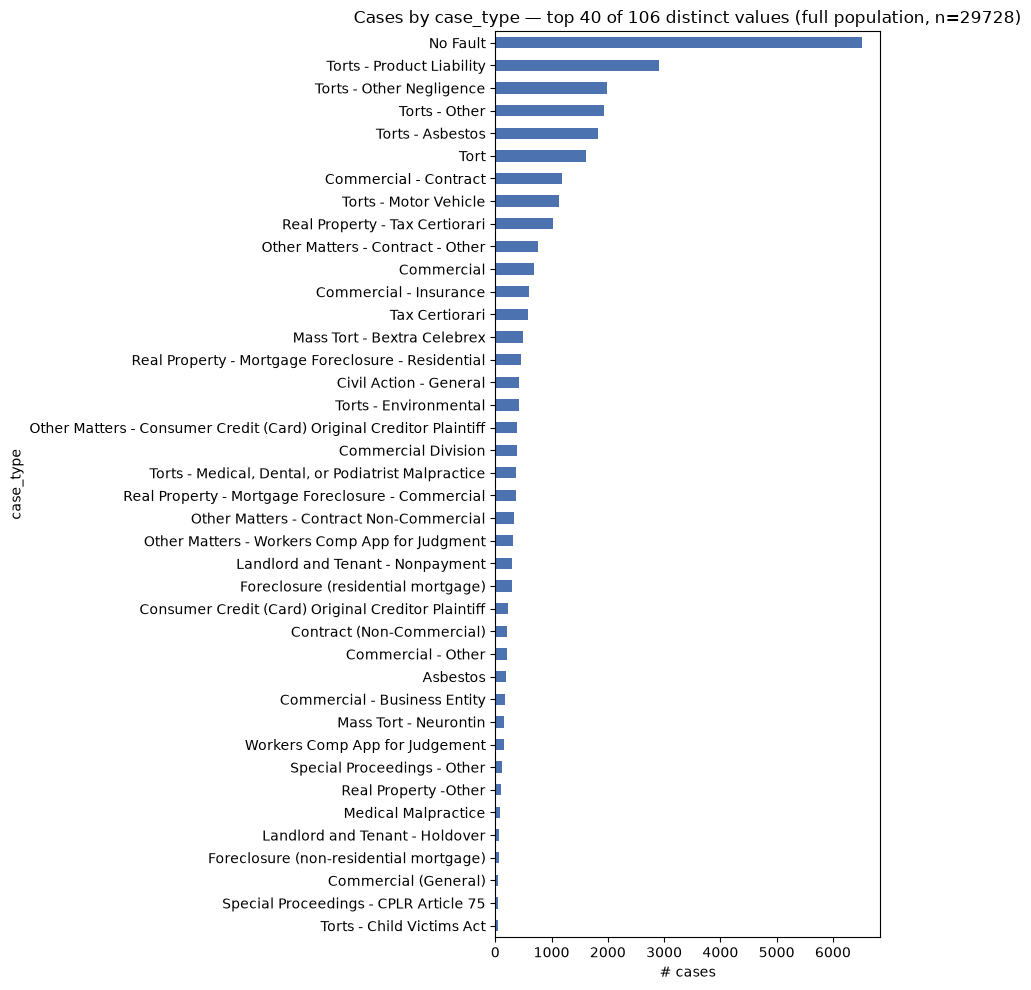

In [4]:
TOP_N = 40
fig, ax = plt.subplots(figsize=(9, 10))
population_df["case_type"].value_counts().head(TOP_N).plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title(f"Cases by case_type — top {TOP_N} of {population_df['case_type'].nunique()} distinct values "
             f"(full population, n={len(population_df)})")
ax.set_xlabel("# cases")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


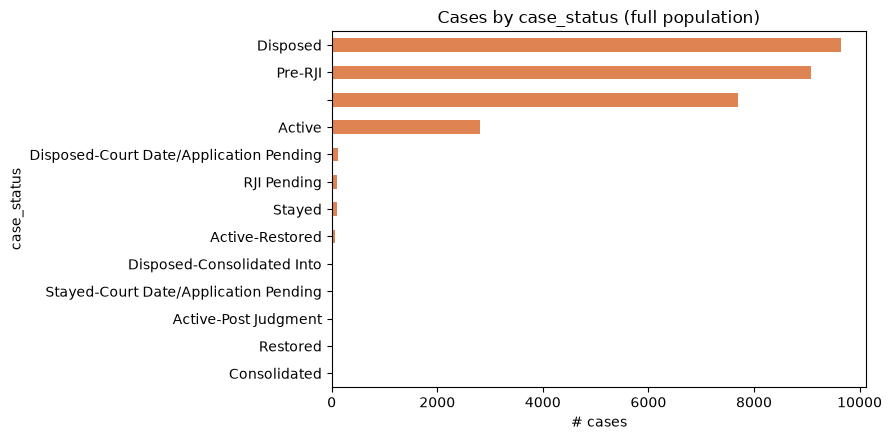

In [5]:
fig, ax = plt.subplots()
population_df["case_status"].value_counts().plot(kind="barh", ax=ax, color="#DD8452")
ax.set_title("Cases by case_status (full population)")
ax.set_xlabel("# cases")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


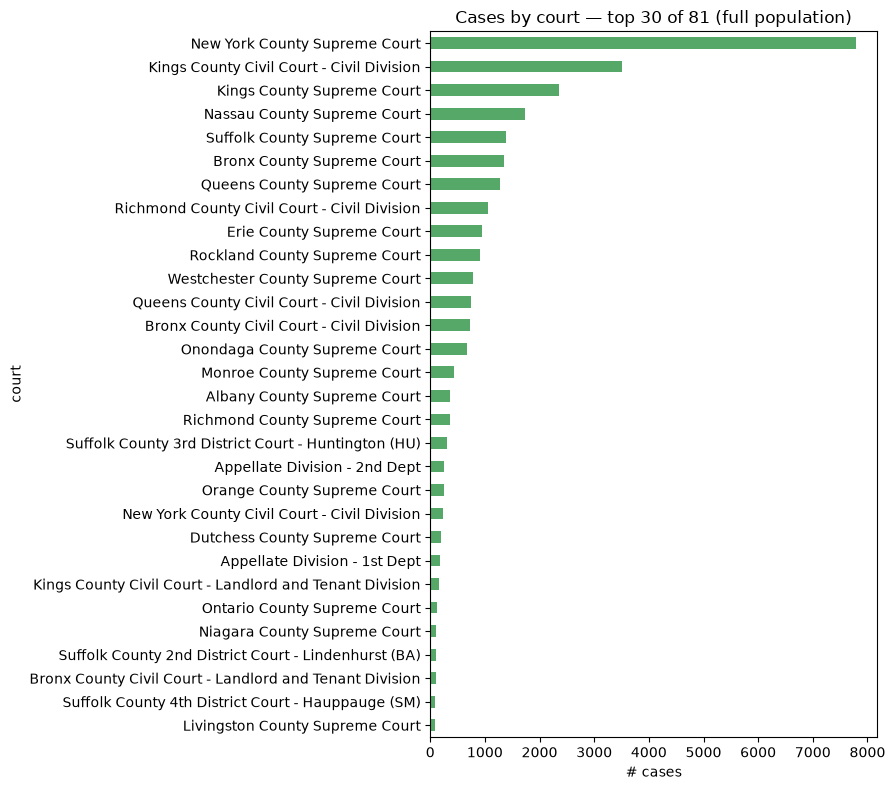

In [6]:
TOP_COURTS = 30
fig, ax = plt.subplots(figsize=(9, 8))
population_df["court"].value_counts().head(TOP_COURTS).plot(kind="barh", ax=ax, color="#55A868")
ax.set_title(f"Cases by court — top {TOP_COURTS} of {population_df['court'].nunique()} (full population)")
ax.set_xlabel("# cases")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


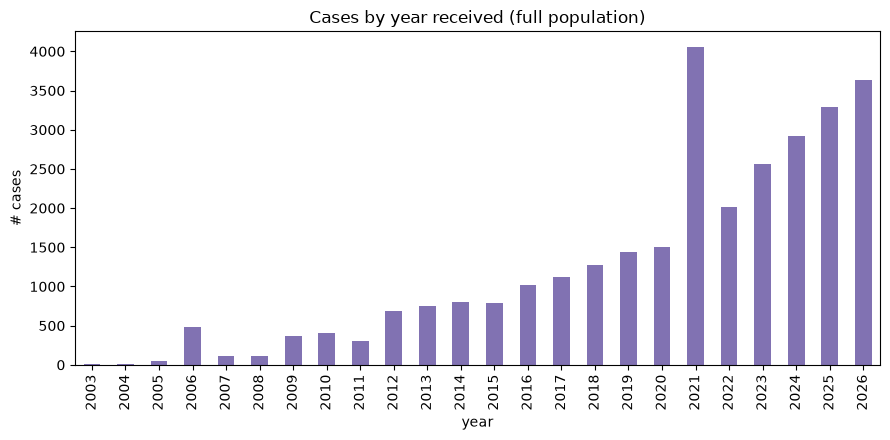

In [7]:
fig, ax = plt.subplots()
population_df["case_received_date"].dt.year.value_counts().sort_index().plot(kind="bar", ax=ax, color="#8172B2")
ax.set_title("Cases by year received (full population)")
ax.set_xlabel("year")
ax.set_ylabel("# cases")
plt.tight_layout()
plt.show()


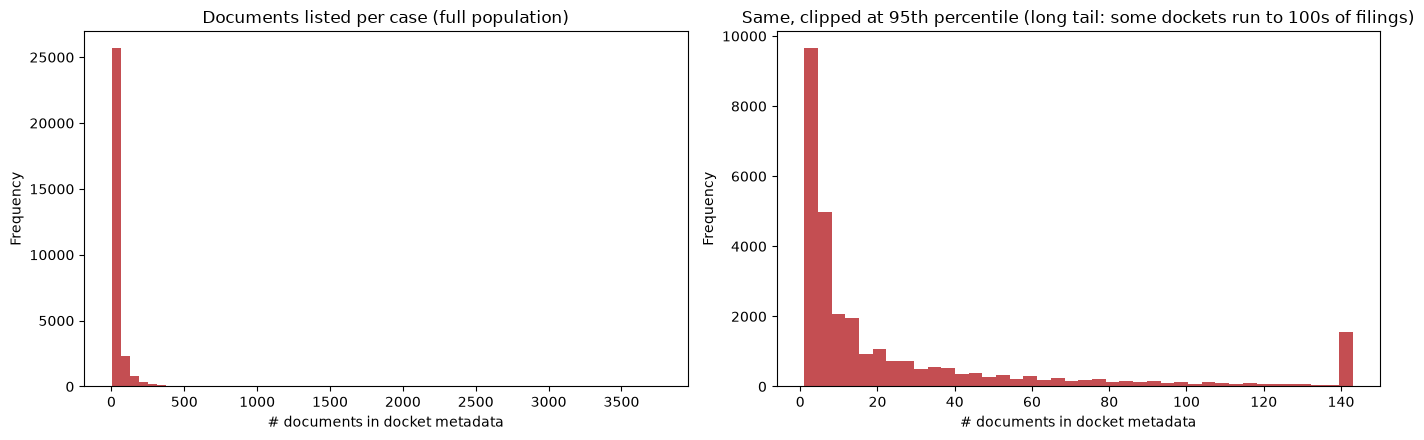

count    29728.000000
mean        34.839108
std         93.380430
min          1.000000
25%          3.000000
50%          9.000000
75%         30.000000
max       3765.000000
Name: num_documents, dtype: float64

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

population_df["num_documents"].plot(kind="hist", bins=60, ax=axes[0], color="#C44E52")
axes[0].set_title("Documents listed per case (full population)")
axes[0].set_xlabel("# documents in docket metadata")

population_df["num_documents"].clip(upper=population_df["num_documents"].quantile(0.95)).plot(
    kind="hist", bins=40, ax=axes[1], color="#C44E52"
)
axes[1].set_title("Same, clipped at 95th percentile (long tail: some dockets run to 100s of filings)")
axes[1].set_xlabel("# documents in docket metadata")

plt.tight_layout()
plt.show()

population_df["num_documents"].describe()


### Document types across the full population

Total documents across all 29728 cases: 1,035,697
Distinct document_name values: 933


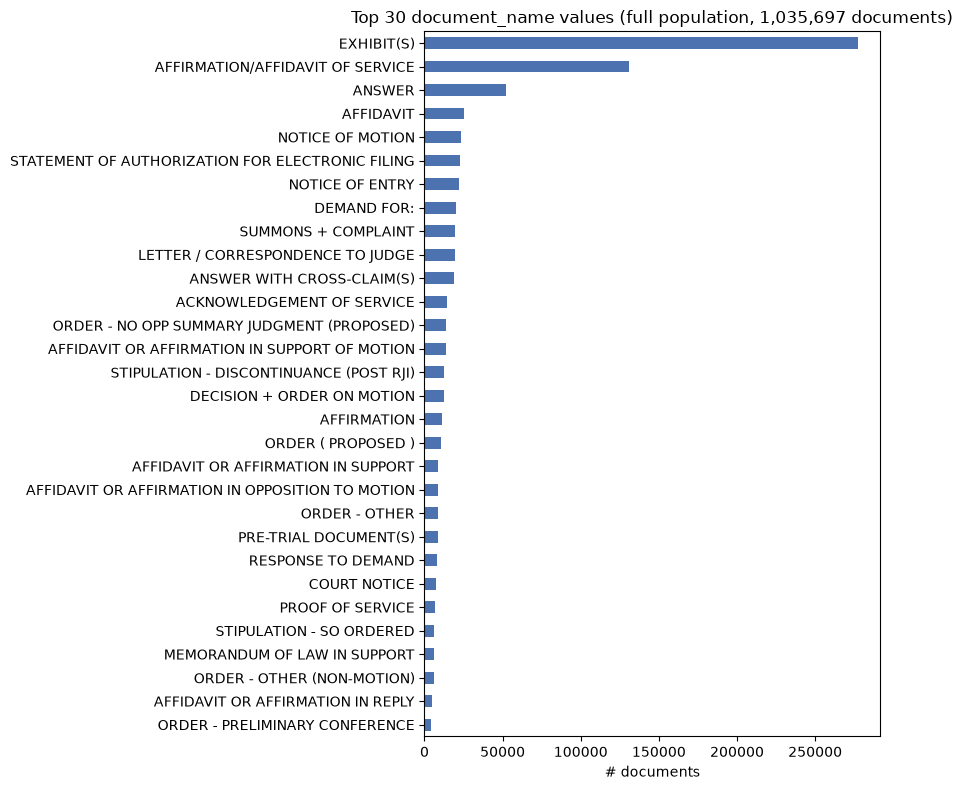

In [9]:
print(f"Total documents across all {len(population_df)} cases: {sum(doc_name_counter.values()):,}")
print(f"Distinct document_name values: {len(doc_name_counter)}")

TOP_N = 30
top_doc_names = pd.Series(dict(doc_name_counter.most_common(TOP_N)))
fig, ax = plt.subplots(figsize=(9, 8))
top_doc_names.plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title(f"Top {TOP_N} document_name values (full population, {sum(doc_name_counter.values()):,} documents)")
ax.set_xlabel("# documents")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 2. Classifier sample

The stratified sample built for the product-liability/personal-injury vs.
other binary classifier (see `scripts/build_classification_sample.py`):
label 1 = product liability / personal injury torts (+ a caption-keyword
class-action match), label 0 = a roughly uniform sample across every other
`case_type` bucket. This is the answer to "why did the old chart only show
~8 mass-tort types" — that was every case with text extracted so far, not a
deliberate sample; this section is the deliberate one.


Sample size: 1150 (350 positive / 800 negative)


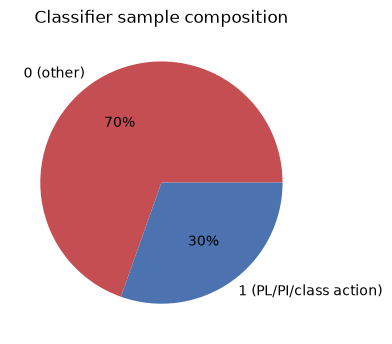

In [10]:
if SAMPLE_IDS_PATH.exists():
    sample = json.load(open(SAMPLE_IDS_PATH))
    positive_ids = set(sample["positive_ids"])
    negative_ids = set(sample["negative_ids"])
    sample_ids = positive_ids | negative_ids

    sample_df = population_df[population_df["case_id"].isin(sample_ids)].copy()
    sample_df["label"] = sample_df["case_id"].apply(lambda cid: 1 if cid in positive_ids else 0)

    print(f"Sample size: {len(sample_df)} ({len(positive_ids)} positive / {len(negative_ids)} negative)")

    fig, ax = plt.subplots(figsize=(4, 4))
    sample_df["label"].value_counts().rename({1: "1 (PL/PI/class action)", 0: "0 (other)"}).plot(
        kind="pie", ax=ax, autopct="%1.0f%%", ylabel="", colors=["#C44E52", "#4C72B0"]
    )
    ax.set_title("Classifier sample composition")
    plt.tight_layout()
    plt.show()
else:
    print(f"{SAMPLE_IDS_PATH} not found - run scripts/build_classification_sample.py first.")
    sample_df = None


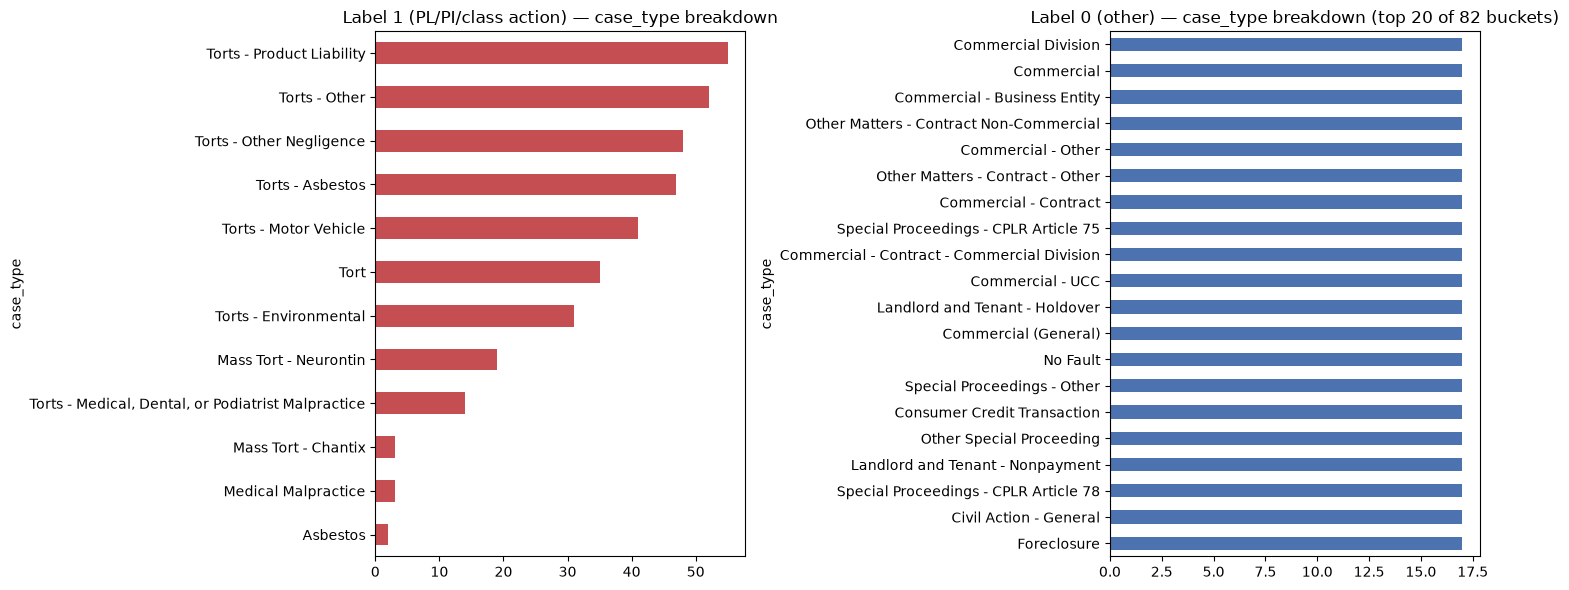

In [11]:
if sample_df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    sample_df[sample_df["label"] == 1]["case_type"].value_counts().head(20).plot(
        kind="barh", ax=axes[0], color="#C44E52"
    )
    axes[0].set_title("Label 1 (PL/PI/class action) — case_type breakdown")
    axes[0].invert_yaxis()

    sample_df[sample_df["label"] == 0]["case_type"].value_counts().head(20).plot(
        kind="barh", ax=axes[1], color="#4C72B0"
    )
    axes[1].set_title("Label 0 (other) — case_type breakdown (top 20 of "
                       f"{sample_df[sample_df['label']==0]['case_type'].nunique()} buckets)")
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()


## 3. Text-extraction subset (`data/extraction/ny_classification`)

Everything below only covers cases that actually have Docling-extracted
text on disk right now. This set is growing as
`scripts/export_classification_sample.py` downloads and parses the
classifier sample in the background - re-run this notebook later to see
more coverage.


In [12]:
case_dirs = sorted(p.name for p in EXTRACTION_DIR.iterdir() if p.is_dir() and p.name.startswith("case_"))
print(f"Cases with docling extraction output: {len(case_dirs)}")

case_meta = {}
missing_metadata = []
for case_id in case_dirs:
    meta_path = CASES_DIR / case_id / f"{case_id}.json"
    if meta_path.exists():
        with open(meta_path) as f:
            case_meta[case_id] = json.load(f)
    else:
        missing_metadata.append(case_id)

print(f"Loaded metadata for {len(case_meta)} cases")
if missing_metadata:
    print(f"Missing metadata JSON for {len(missing_metadata)} case(s): {missing_metadata}")


Cases with docling extraction output: 98
Loaded metadata for 98 cases


In [13]:
doc_meta_rows = []
stem_to_name = []
for case_id, meta in case_meta.items():
    for doc in meta.get("documents", []):
        name = doc.get("document_name")
        local_path = doc.get("local_document_path") or ""
        stem = Path(local_path).stem if local_path else None
        docling_path = (
            EXTRACTION_DIR / case_id / "docling" / "documents" / f"{stem}.docling.json"
            if stem else None
        )
        doc_meta_rows.append({
            "case_id": case_id,
            "document_doc_index": doc.get("document_doc_index"),
            "document_name": name,
            "extracted": bool(docling_path and docling_path.exists()),
        })
        for path_field in ("local_document_path", "local_confirmation_path"):
            lp = doc.get(path_field)
            if lp:
                stem_to_name.append({"case_id": case_id, "stem": Path(lp).stem, "document_name": name})

doc_meta_df = pd.DataFrame(doc_meta_rows)
stem_name_df = pd.DataFrame(stem_to_name).drop_duplicates(subset=["case_id", "stem"])

print(f"Documents listed (for these {len(case_meta)} cases): {len(doc_meta_df)}")
print(f"Documents with a docling extraction available: "
      f"{doc_meta_df['extracted'].sum()} ({doc_meta_df['extracted'].mean():.1%})")


Documents listed (for these 98 cases): 1345
Documents with a docling extraction available: 1229 (91.4%)


In [14]:
TEXT_LABELS = ["text", "list_item", "section_header", "page_header", "page_footer", "footnote"]

def analyze_docling_file(path):
    with open(path) as f:
        d = json.load(f)
    texts = d.get("texts", [])
    label_counts = Counter(t.get("label") for t in texts)
    full_text = " ".join(t.get("text", "") for t in texts if t.get("text"))
    row = {
        "num_pages": len(d.get("pages", {})),
        "num_text_elements": len(texts),
        "num_groups": len(d.get("groups", [])),
        "num_tables": len(d.get("tables", [])),
        "num_pictures": len(d.get("pictures", [])),
        "num_words": len(full_text.split()),
        "num_chars": len(full_text),
    }
    for label in TEXT_LABELS:
        row[f"label_{label}"] = label_counts.get(label, 0)
    return row


docling_rows = []
for case_id in case_dirs:
    for kind in ("documents", "confirmations"):
        folder = EXTRACTION_DIR / case_id / "docling" / kind
        if not folder.exists():
            continue
        for path in sorted(folder.glob("*.docling.json")):
            stem = path.name[: -len(".docling.json")]
            row = {"case_id": case_id, "kind": kind, "stem": stem}
            try:
                row.update(analyze_docling_file(path))
            except Exception as exc:
                row["error"] = str(exc)
            docling_rows.append(row)

docling_df = pd.DataFrame(docling_rows)
docling_df = docling_df.merge(stem_name_df, on=["case_id", "stem"], how="left")

print(f"Docling files analyzed: {len(docling_df)}")
if "error" in docling_df.columns:
    n_errors = docling_df["error"].notna().sum()
    if n_errors:
        print(f"Failed to parse {n_errors} file(s)")
docling_df.head()


Docling files analyzed: 2468


,case_id,kind,stem,num_pages,num_text_elements,num_groups,num_tables,num_pictures,num_words,num_chars,label_text,label_list_item,label_section_header,label_page_header,label_page_footer,label_footnote,document_name
0,case_1,documents,document_LVMl58M4lUBCzXgnCXnv_PLUS_g==,64,1624,101,0,0,17638,124331,1127,132,27,190,125,23,SUMMONS + COMPLAINT
1,case_1,confirmations,document_LVMl58M4lUBCzXgnCXnv_PLUS_g==,1,26,3,1,2,150,1075,14,0,9,0,2,1,SUMMONS + COMPLAINT
2,case_10,documents,document_1pIeSZWiLDw2MEItqTND3w==,1,84,6,0,1,620,3573,67,3,1,1,1,0,AFFIRMATION/AFFIDAVIT OF SERVICE
3,case_10,documents,document_7a7INdL3Uf8KxUBclTrPYg==,1,104,4,0,2,626,3601,92,1,1,1,1,0,AFFIRMATION/AFFIDAVIT OF SERVICE
4,case_10,documents,document_CbvQAEPemU_bkNqNyxkTSA==,1,99,12,0,2,624,3598,81,8,1,1,1,0,AFFIRMATION/AFFIDAVIT OF SERVICE


In [15]:
if "error" in docling_df.columns:
    failed = docling_df[docling_df["error"].notna()][["case_id", "kind", "stem", "error"]]
    if len(failed):
        print(f"{len(failed)} docling JSON file(s) are empty/corrupt and were excluded from the stats below:")
        display(failed)


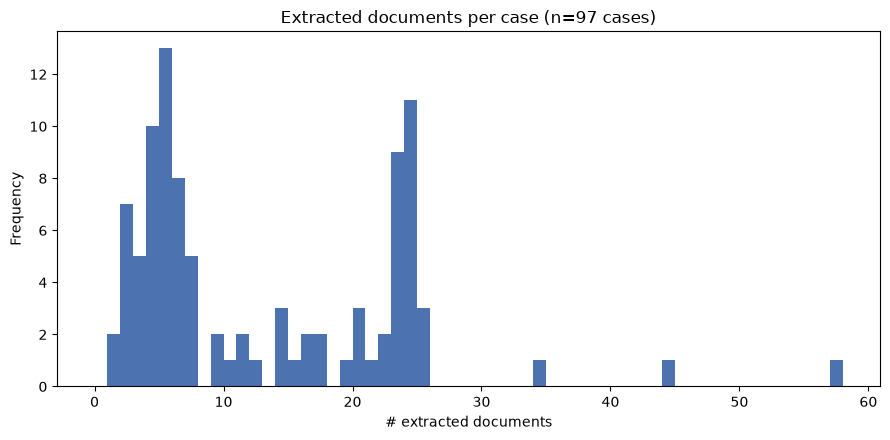

count    97.000000
mean     12.670103
std      10.386010
min       1.000000
25%       5.000000
50%       7.000000
75%      23.000000
max      57.000000
dtype: float64

In [16]:
docs_only = docling_df[docling_df["kind"] == "documents"]

docs_per_case = docs_only.groupby("case_id").size()
fig, ax = plt.subplots()
docs_per_case.plot(kind="hist", bins=range(0, docs_per_case.max() + 2), ax=ax, color="#4C72B0")
ax.set_title(f"Extracted documents per case (n={len(docs_per_case)} cases)")
ax.set_xlabel("# extracted documents")
plt.tight_layout()
plt.show()

docs_per_case.describe()


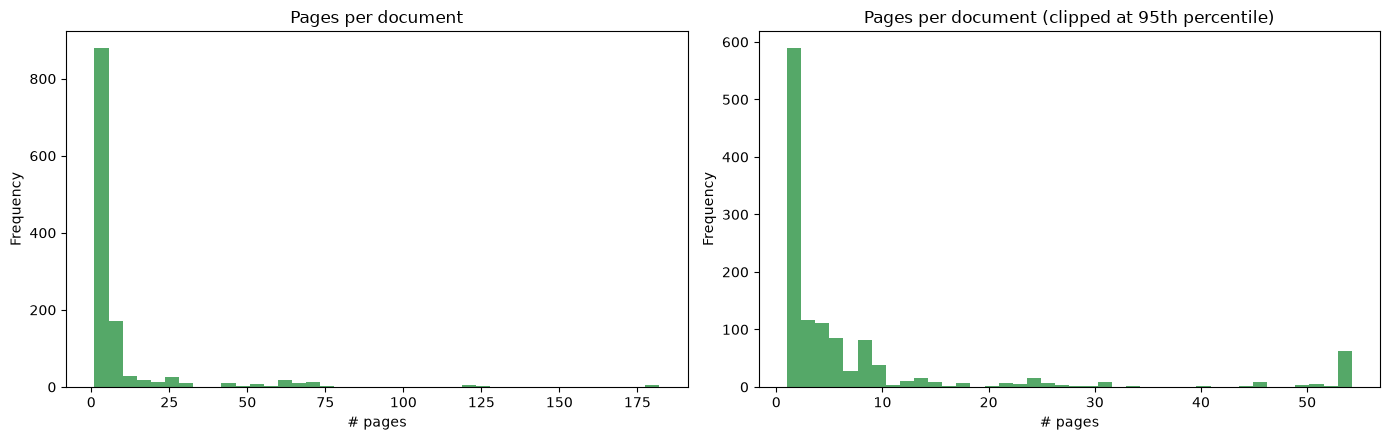

count    1229.000000
mean        9.223759
std        20.387362
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       182.000000
Name: num_pages, dtype: float64

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

docs_only["num_pages"].plot(kind="hist", bins=40, ax=axes[0], color="#55A868")
axes[0].set_title("Pages per document")
axes[0].set_xlabel("# pages")

docs_only["num_pages"].clip(upper=docs_only["num_pages"].quantile(0.95)).plot(
    kind="hist", bins=40, ax=axes[1], color="#55A868"
)
axes[1].set_title("Pages per document (clipped at 95th percentile)")
axes[1].set_xlabel("# pages")

plt.tight_layout()
plt.show()

docs_only["num_pages"].describe()


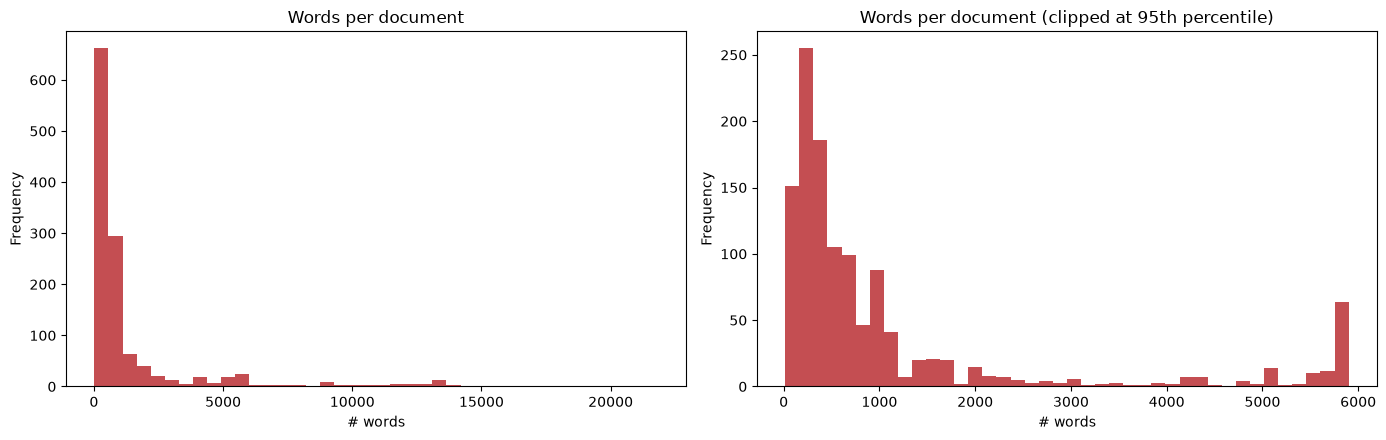

count     1229.000000
mean      1405.684296
std       2660.347741
min         16.000000
25%        233.000000
50%        485.000000
75%       1023.000000
max      21822.000000
Name: num_words, dtype: float64

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

docs_only["num_words"].plot(kind="hist", bins=40, ax=axes[0], color="#C44E52")
axes[0].set_title("Words per document")
axes[0].set_xlabel("# words")

docs_only["num_words"].clip(upper=docs_only["num_words"].quantile(0.95)).plot(
    kind="hist", bins=40, ax=axes[1], color="#C44E52"
)
axes[1].set_title("Words per document (clipped at 95th percentile)")
axes[1].set_xlabel("# words")

plt.tight_layout()
plt.show()

docs_only["num_words"].describe()


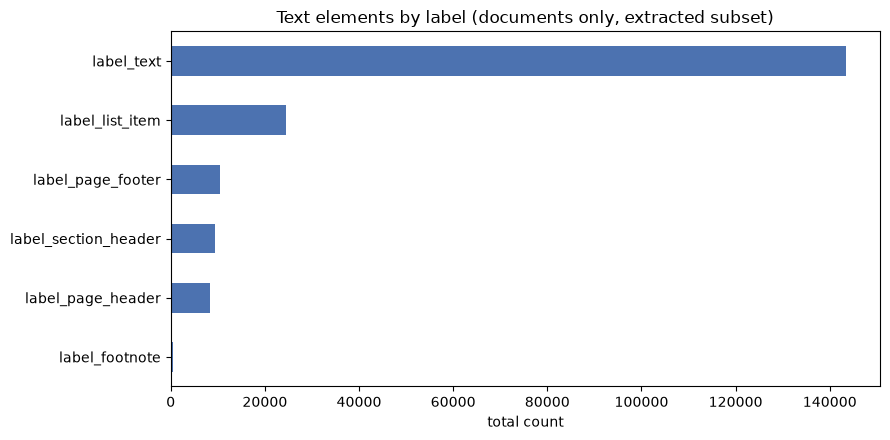

In [19]:
label_totals = docs_only[[f"label_{l}" for l in TEXT_LABELS]].sum().sort_values(ascending=False)
fig, ax = plt.subplots()
label_totals.plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Text elements by label (documents only, extracted subset)")
ax.set_xlabel("total count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


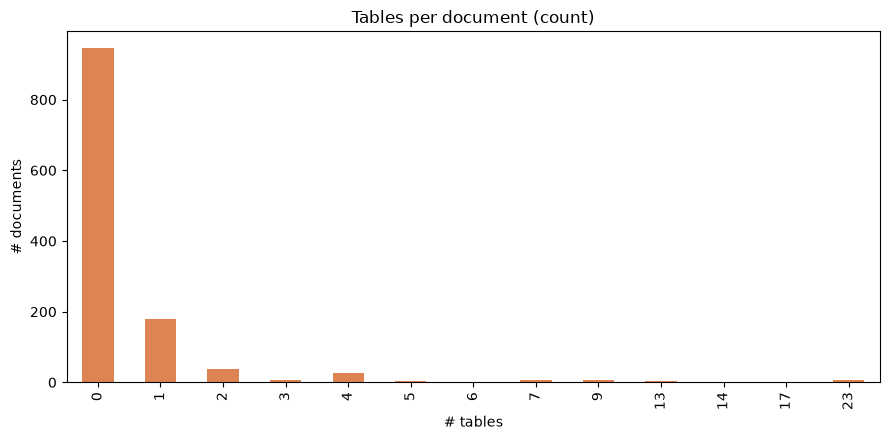

Documents with >=1 table: 283 / 1229
Documents with >=1 picture: 1064 / 1229


In [20]:
fig, ax = plt.subplots()
docs_only["num_tables"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#DD8452")
ax.set_title("Tables per document (count)")
ax.set_xlabel("# tables")
ax.set_ylabel("# documents")
plt.tight_layout()
plt.show()

print(f"Documents with >=1 table: {(docs_only['num_tables'] > 0).sum()} / {len(docs_only)}")
print(f"Documents with >=1 picture: {(docs_only['num_pictures'] > 0).sum()} / {len(docs_only)}")


## Summary

In [21]:
summary = {
    "--- full population (ny_after_search) ---": "",
    "cases in full population": len(population_df),
    "distinct case_type values": population_df["case_type"].nunique(),
    "distinct courts": population_df["court"].nunique(),
    "total documents (docket metadata)": sum(doc_name_counter.values()),
    "--- classifier sample ---": "",
    "sample size": len(sample_df) if sample_df is not None else "n/a",
    "--- text-extraction subset (ny_classification) ---": "",
    "cases with extraction output": len(case_dirs),
    "extracted 'documents' files": len(docs_only),
    "median pages/document": docs_only["num_pages"].median(),
    "median words/document": docs_only["num_words"].median(),
    "total extracted words": int(docs_only["num_words"].sum()),
}
pd.Series(summary)


--- full population (ny_after_search) ---                    
cases in full population                                29728
distinct case_type values                                 106
distinct courts                                            81
total documents (docket metadata)                     1035697
--- classifier sample ---                                    
sample size                                              1150
--- text-extraction subset (ny_classification) ---           
cases with extraction output                               98
extracted 'documents' files                              1229
median pages/document                                     3.0
median words/document                                   485.0
total extracted words                                 1727586
dtype: object